<h2>Задание 2</h2>
<b>Реализовать алгоритм Флойда-Уоршелла</b> и найти диаметр, радиус и центр


графа из файла Graph2.csv (в каждой строке даны ребро и его вес)


<h3>Записываем файл из csv в DataFrame</h3>

In [215]:
import pandas as pd

link ="C:/Users/User/Desktop/Graph2.csv"

df = pd.read_csv(link, names = ['from','to', 'weights'])
df.head()

,from,to,weights
0,41,70,3
1,41,25,1
2,11,27,7
3,11,82,10
4,91,38,5


<h3>Выделим ребра и вершины</h3>

In [218]:
import numpy as np
edges = np.array([np.array([df['from'].tolist()[i], df['to'].tolist()[i]])
            for i in range(len(df))])


nodes = set()

for edge in edges:
    nodes.add(edge[0])
    nodes.add(edge[1])
nodes = np.array(list(nodes))
nodes[:5]

array([1, 2, 3, 4, 5])

<h3>Изобразим граф</h3>

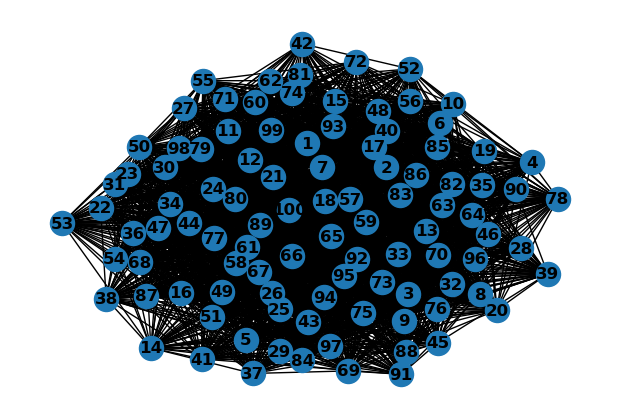

In [221]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()


G.add_nodes_from(nodes)
G.add_edges_from(edges)

plt.figure(figsize = (6,4))
nx.draw(G, with_labels = True, font_weight = 'bold')
plt.show()

<h3>Реализация алгоритма</h3>

In [224]:

def floydWarshall(graph):
    V = len(graph)
    for k in range(V):
        for i in range(V):
            for j in range(V):
                graph[i][j] = min(graph[i][j], graph[i][k] + graph[k][j])
    return graph

<h3>Приводим граф к нужному формату</h3>

In [227]:
import math 
graph = np.array([np.array([math.inf for _ in range(100)]) for _ in range(100)])


In [229]:
edges_with_weights = np.array([np.array([df['from'].tolist()[i], df['to'].tolist()[i], df['weights'].tolist()[i]])
            for i in range(len(df))] )

<h4>Граф до применения алгоритма</h4>

In [231]:
for it in edges_with_weights:
    graph[it[0] - 1][it[1] - 1] = it[2]
    graph[it[1] - 1][it[0] - 1] = it[2]
for i in range(len(graph)):
    graph[i][i] = 0
graph

array([[ 0.,  6., inf, ...,  3.,  4., inf],
       [ 6.,  0., inf, ..., inf, inf,  5.],
       [inf, inf,  0., ..., inf,  5.,  3.],
       ...,
       [ 3., inf, inf, ...,  0., inf,  7.],
       [ 4., inf,  5., ..., inf,  0., inf],
       [inf,  5.,  3., ...,  7., inf,  0.]])

<h4>Граф после применения алгоритма</h4>

In [235]:
floydWarshall(graph)
#Граф после применения к нему алгоритма
graph

array([[0., 3., 2., ..., 3., 4., 3.],
       [3., 0., 3., ..., 2., 2., 4.],
       [2., 3., 0., ..., 3., 4., 3.],
       ...,
       [3., 2., 3., ..., 0., 2., 3.],
       [4., 2., 4., ..., 2., 0., 4.],
       [3., 4., 3., ..., 3., 4., 0.]])

<h3>Теперь ответим на поставленные вопросы (вспомним термины)</h3>
<b>Эксцентриситет вершины</b>- мааксимальное расстояние от этой вершины до всех остальных.

<h5>Диаметром графа</h5> - называют число, равное расстоянию между наиболее удаленными друг от друга вершинами графа

Максимальный эксцентриситет среди всех вершин.

In [238]:
diametr = 0
for i in range(len(graph)):
    for j in range(len(graph[i])):
        if diametr < graph[i][j]:
            diametr = graph[i][j]
         
print('Диаметр графа равен {}'.format(int(diametr)))

Диаметр графа равен 5


In [239]:
#Да действительно диаметр равен 5)
graph.max()

5.0

<h5>Радиусом r графа</h5> - называется минимальный эксцентриситет среди всех вершин графа.

Минимальный эксцентриситет среди всех вершин.

In [241]:
radius = math.inf
for i in range(len(graph)):
    s = graph[i].max()
    if s < radius :
        radius = s
print('Радиусом графа равен {}'.format(int(radius)))

Радиусом графа равен 3


<H5>Центр (или центр Жордана) графа</H5> — это множество всех вершин с минимальным эксцентриситетом. <br>(То есть множество всех вершин A, для которой максимальное расстояние p(A, B) до других вершин B минимально.)

Вершины с наименьшим эксцентриситетом (равным радиусу).

In [247]:
centers = []
for i in range(len(graph)):
    s = graph[i].max()
    if s == radius:
        centers.append(i + 1)
print('Центром графа является вершина под номером {}'.format(centers))

Центром графа является вершина под номером [46]


<h4>Рассмотрим вершину под номером 46</h4>

In [250]:
print("""Минимальное расстояние {} 
        Максимальное расстояние {}
                Растояние от всех вершин до всех:""".format(graph[46 - 1].min(), graph[46 -1 ].max()))
for i in range(len(graph[45])):
    print('Distanse from 46 to {} equal = {}'.format(i + 1, graph[45][i]))

Минимальное расстояние 0.0 
        Максимальное расстояние 3.0
                Растояние от всех вершин до всех:
Distanse from 46 to 1 equal = 2.0
Distanse from 46 to 2 equal = 2.0
Distanse from 46 to 3 equal = 3.0
Distanse from 46 to 4 equal = 2.0
Distanse from 46 to 5 equal = 2.0
Distanse from 46 to 6 equal = 2.0
Distanse from 46 to 7 equal = 3.0
Distanse from 46 to 8 equal = 3.0
Distanse from 46 to 9 equal = 3.0
Distanse from 46 to 10 equal = 3.0
Distanse from 46 to 11 equal = 3.0
Distanse from 46 to 12 equal = 3.0
Distanse from 46 to 13 equal = 3.0
Distanse from 46 to 14 equal = 2.0
Distanse from 46 to 15 equal = 3.0
Distanse from 46 to 16 equal = 3.0
Distanse from 46 to 17 equal = 2.0
Distanse from 46 to 18 equal = 1.0
Distanse from 46 to 19 equal = 2.0
Distanse from 46 to 20 equal = 2.0
Distanse from 46 to 21 equal = 2.0
Distanse from 46 to 22 equal = 3.0
Distanse from 46 to 23 equal = 2.0
Distanse from 46 to 24 equal = 3.0
Distanse from 46 to 25 equal = 3.0
Distanse from 46 to 